# 1. IMPORT DATASET

In [ ]:
import kagglehub

# Download latest version
path= kagglehub.dataset_download("aliabdelmenam/rdd-2022")
print("Path to dataset files:", path)

100%|██████████| 9.90G/9.90G [01:50<00:00, 96.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1


In [ ]:
import os
from pathlib import Path
os.listdir(path)


['RDD_SPLIT']

In [ ]:
from pathlib import Path

dataset_path = Path(path) / "RDD_SPLIT"

train_path = dataset_path /"train"
test_path = dataset_path /"test"
val_path = dataset_path /"val"

train_images_path = train_path/"images"
test_images_path = test_path/"images"
val_images_path = val_path/"images"

train_labels_path = train_path/"labels"
test_labels_path = test_path/"labels"
val_labels_path = val_path/"labels"

os.listdir(train_path)

['images', 'labels']

In [ ]:
train_images = list(train_images_path.glob("*.jpg"))
train_labels = list(train_labels_path.glob("*.txt"))

test_images = list(test_images_path.glob("*.jpg"))
test_labels = list(test_labels_path.glob("*.txt"))

print("Train Images:", len(train_images))
print("Train Labels:", len(train_labels))

print("Test Images:", len(test_images))
print("Test Labels:", len(test_labels))

Train Images: 26869
Train Labels: 26869
Test Images: 5758
Test Labels: 5758


# 2.Understanding data

In [ ]:
classes = set()
for file in train_labels:
  with open(file,"r") as f:
    for line in f :
      if line.strip():
        class_id = int(line.split()[0])
        classes.add(class_id)

print("Classes found:", sorted(classes))
print("Number of classes:", len(classes))


Classes found: [0, 1, 2, 3, 4]
Number of classes: 5


In [ ]:
import os

for file in train_labels:
    if os.path.getsize(file) > 0:
        print("File:", file)
        with open(file, "r") as f:
            print(f.read())
        break

File: /root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/train/labels/Japan_008566.txt
0 0.821667 0.525833 0.066667 0.171667
0 0.883333 0.717500 0.173333 0.188333
1 0.644167 0.448333 0.261667 0.056667
1 0.690000 0.647500 0.190000 0.061667
1 0.668333 0.300833 0.663333 0.058333



In [ ]:
# label_path= train_labels[0]
# image_path= train_images[0]
# print(label_path.name)
# print(image_path.name)
train_images = sorted(train_images_path.glob("*.jpg"))
train_labels = sorted(train_labels_path.glob("*.txt"))
print(train_images[0])
print(train_labels[0])

/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/train/images/China_Drone_000001.jpg
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/train/labels/China_Drone_000001.txt


In [ ]:
from pathlib import Path
from PIL import Image
from PIL import ImageDraw
image_path = train_images[594]
image = Image.open(image_path)
draw = ImageDraw.Draw(image)
label_path = train_labels_path / f"{image_path.stem}.txt"      # stem = Give me the filename without the extension.
print(image_path.name)
print(label_path.name)

China_Drone_000837.jpg
China_Drone_000837.txt


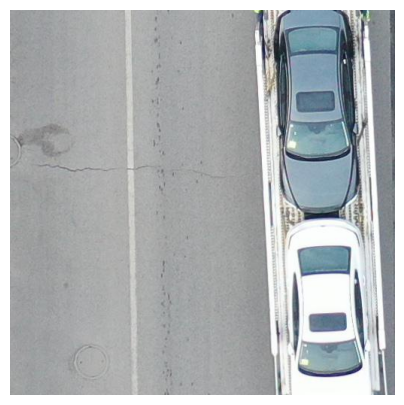

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
image_2 = Image.open(image_path)
plt.imshow(image_2)
plt.axis("off")
plt.show()

# 3. Creating file for YOLO

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import yaml

dataset_root = "/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT"

data = {
    "path": dataset_root,
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 5,
    "names": ["D00", "D10", "D20", "D40", "D50"]
}

yaml_path = "/content/drive/MyDrive/YOLO_Projects/road_damage_detector/data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

In [ ]:
import os

print(os.path.exists(yaml_path))

True


# 4. JUST DRAW  BOUNDING BOX :

In [ ]:
with open(label_path, "r") as f:
    lines = f.readlines()
print(lines)

['1 0.309570 0.409180 0.501953 0.083984\n']


In [ ]:
line = lines[0]

class_id, x_center, y_center, width, height = map(float, line.split())

print(class_id)
print(x_center)
print(y_center)
print(width)
print(height)

1.0
0.30957
0.40918
0.501953
0.083984


In [ ]:
img_w, img_h = image.size

print(img_w, img_h)

512 512


In [ ]:
x_center *= img_w
y_center *= img_h

width *= img_w
height *= img_h

print(x_center, y_center)
print(width, height)

158.49984 209.50016
256.999936 42.999808


In [ ]:
x1 = x_center - width / 2
y1 = y_center - height / 2

x2 = x_center + width / 2
y2 = y_center + height / 2

print("Top Left     :", (x1, y1))
print("Bottom Right :", (x2, y2))

Top Left     : (29.99987200000001, 188.00025599999998)
Bottom Right : (286.99980800000003, 231.000064)


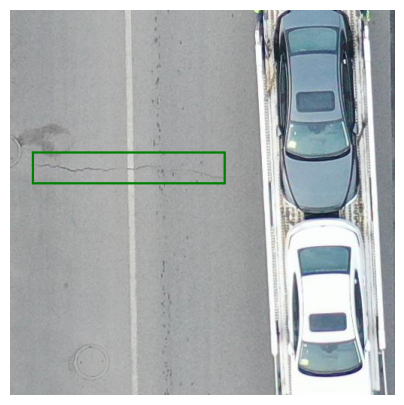

In [ ]:
draw.rectangle(
    [x1, y1, x2, y2],
    outline="green",
    width=3
)
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.show()

# MODEL

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
model.train(
    data="data.yaml",
    epochs=30,
    imgsz=640,  ## 640×640 is the standard choice for YOLO.
    batch=32,
    workers=2,
    device=device,
    project="/content/drive/MyDrive/YOLO_Projects",
    name="road_damage_detector",
    save = True,
    save_period=1,   # This is very important for you because Kaggle has been crashing.
    cache=False,
    verbose=False
)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road_damage_detector, nbs=64, nms=False, opset=None

# So from 22 to 30 i run the epochs again with using the pretrained wieght form above. The code is not present here !! ( as i switch the file form collab to vs code for to create repository)